Notebook นี้อธิบายวิธีการสำรวจและเตรียมข้อมูลสำหรับการสร้างโมเดล Notebook นี้มีโครงสร้างดังนี้

 - เกี่ยวกับ Dataset (About Dataset)
 - สรุปข้อมูล (Data Summary)
 - Feature Engineering
 - การวิเคราะห์ค่าที่หายไป (Missing Value Analysis)
 - การวิเคราะห์ Outlier (Outlier Analysis)
 - การวิเคราะห์ Correlation (Correlation Analysis)
 - การแสดงภาพการกระจายของข้อมูล (Visualizing Distribution Of Data)
 - การแสดงภาพ Count Vs (Month, Season, Hour, Weekday, Usertype)
 - การเติม 0 ใน Windspeed โดยใช้ Random Forest
 - Linear Regression Model
 - Regularization Models
 - Ensemble Models

## เกี่ยวกับ Dataset (About Dataset)

#### **ภาพรวม (Overview)**

ระบบ Bike sharing เป็นวิธีการเช่ารถจักรยานที่กระบวนการสมัครสมาชิก, เช่า, และคืนรถจักรยานเป็นไปโดยอัตโนมัติผ่านเครือข่ายของตู้ Kiosk ทั่วเมือง ด้วยระบบเหล่านี้ ผู้คนสามารถเช่ารถจักรยานจากที่หนึ่งและคืนที่อีกที่หนึ่งได้ตามความต้องการ ปัจจุบันมีโปรแกรม Bike-sharing มากกว่า 500 แห่งทั่วโลก

#### **ฟิลด์ข้อมูล (Data Fields)**

* datetime - วันที่ + เวลาเป็นรายชั่วโมง
* season -  1 = ฤดูใบไม้ผลิ (spring), 2 = ฤดูร้อน (summer), 3 = ฤดูใบไม้ร่วง (fall), 4 = ฤดูหนาว (winter)
* holiday - วันนั้นถือเป็นวันหยุดหรือไม่
* workingday - วันนั้นไม่ใช่ทั้งวันหยุดสุดสัปดาห์และวันหยุดนักขัตฤกษ์หรือไม่
* weather - 
    * 1: ท้องฟ้าแจ่มใส (Clear), เมฆเล็กน้อย (Few clouds), เมฆบางส่วน (Partly cloudy), เมฆบางส่วน (Partly cloudy)
    * 2: หมอก + เมฆมาก (Mist + Cloudy), หมอก + เมฆแตก (Mist + Broken clouds), หมอก + เมฆเล็กน้อย (Mist + Few clouds), หมอก (Mist)
    * 3: หิมะตกเล็กน้อย (Light Snow), ฝนตกเล็กน้อย + พายุฝนฟ้าคะนอง + เมฆกระจาย (Light Rain + Thunderstorm + Scattered clouds), ฝนตกเล็กน้อย + เมฆกระจาย (Light Rain + Scattered clouds)
    * 4: ฝนตกหนัก + ลูกเห็บ + พายุฝนฟ้าคะนอง + หมอก (Heavy Rain + Ice Pallets + Thunderstorm + Mist), หิมะ + หมอก (Snow + Fog)
* temp - อุณหภูมิในหน่วย Celsius
* atemp - อุณหภูมิที่ "รู้สึกเหมือน" (feels like) ในหน่วย Celsius
* humidity - ความชื้นสัมพัทธ์ (relative humidity)
* windspeed - ความเร็วลม (wind speed)
* casual - จำนวนการเช่าของผู้ใช้ที่ไม่ได้ลงทะเบียน
* registered - จำนวนการเช่าของผู้ใช้ที่ลงทะเบียน
* count - จำนวนการเช่าทั้งหมด (Dependent Variable)

In [3]:
import pylab
import calendar
import numpy as np
import pandas as pd
import seaborn as sn
from scipy import stats
import missingno as msno
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore", category=DeprecationWarning)
%matplotlib inline

#### **อ่าน Dataset กันเถอะ (Lets Read In The Dataset)**

In [4]:
dailyData = pd.read_csv("train.csv")

## สรุปข้อมูล (Data Summary)

เป็นขั้นตอนแรก มาทำ 3 ขั้นตอนง่ายๆ กับ Dataset กัน

 - ขนาดของ Dataset
 - ดูข้อมูลคร่าวๆ โดยการพิมพ์แถวสองสามแถว
 - ตัวแปรประเภทใดบ้างที่ประกอบเป็นข้อมูลของเรา

#### **รูปร่างของ Dataset (Shape Of The Dataset)**

In [5]:
dailyData.shape

(10886, 12)

#### **ตัวอย่างของแถวแรกๆ (Sample Of First Few Rows)**

In [6]:
dailyData.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


#### **ประเภทข้อมูลของตัวแปร (Variables Data Type)**

In [7]:
dailyData.dtypes

datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

## Feature Engineering

จากผลลัพธ์ข้างต้น เราเห็นว่าคอลัมน์ "season", "holiday", "workingday" และ "weather" ควรเป็นประเภทข้อมูล "categorical" แต่ประเภทข้อมูลปัจจุบันสำหรับคอลัมน์เหล่านั้นคือ "int" มาแปลง Dataset ในลักษณะต่อไปนี้เพื่อให้เราสามารถเริ่มต้นกับ EDA ของเราได้

 - สร้างคอลัมน์ใหม่ "date", "hour", "weekDay", "month" จากคอลัมน์ "datetime"
 - บังคับ (Coerce) datatype ของ "season", "holiday", "workingday" และ "weather" ให้เป็น category
 - ลบคอลัมน์ datetime เนื่องจากเราได้สกัดฟีเจอร์ที่มีประโยชน์จากมันแล้ว

#### **สร้างคอลัมน์ใหม่จากคอลัมน์ "Datetime" (Creating New Columns From "Datetime" Column)**

In [8]:
dailyData["date"] = dailyData.datetime.apply(lambda x : x.split()[0])
dailyData["hour"] = dailyData.datetime.apply(lambda x : x.split()[1].split(":")[0])
dailyData["weekday"] = dailyData.date.apply(lambda dateString : calendar.day_name[datetime.strptime(dateString,"%Y-%m-%d").weekday()])
dailyData["month"] = dailyData.date.apply(lambda dateString : calendar.month_name[datetime.strptime(dateString,"%Y-%m-%d").month])
dailyData["season"] = dailyData.season.map({1: "Spring", 2 : "Summer", 3 : "Fall", 4 :"Winter" })
dailyData["weather"] = dailyData.weather.map({1: " Clear + Few clouds + Partly cloudy + Partly cloudy",\
                                        2 : " Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist ", \
                                        3 : " Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds", \
                                        4 :" Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog " })

#### **บังคับเป็นประเภท Category (Coercing To Category Type)**

In [9]:
categoryVariableList = ["hour","weekday","month","season","weather","holiday","workingday"]
for var in categoryVariableList:
    dailyData[var] = dailyData[var].astype("category")

#### **ลบคอลัมน์ที่ไม่จำเป็น (Dropping Unncessary Columns)**

In [10]:
dailyData  = dailyData.drop(["datetime"],axis=1)

#### **มาเริ่มด้วยการแสดงภาพง่ายๆ ของจำนวนประเภทข้อมูลตัวแปร (Lets Start With Very Simple Visualization Of Variables DataType Count)**

[Text(0.5, 0, 'variableTypeariable Type'),
 Text(0, 0.5, 'Count'),
 Text(0.5, 1.0, 'Variables DataType Count')]

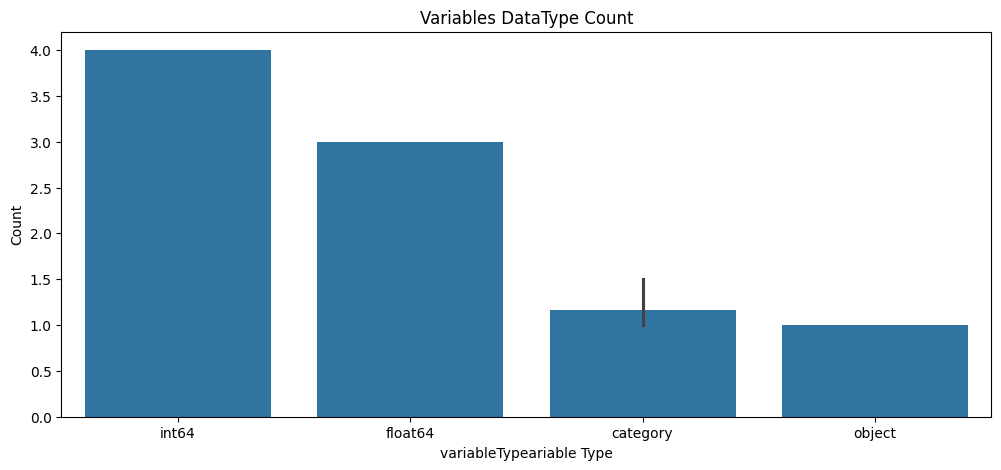

In [11]:
dataTypeDf = pd.DataFrame(dailyData.dtypes.value_counts()).reset_index().rename(columns={"index":"variableType",0:"count"})
fig,ax = plt.subplots()
fig.set_size_inches(12,5)
sn.barplot(data=dataTypeDf,x="variableType",y="count",ax=ax)
ax.set(xlabel='variableTypeariable Type', ylabel='Count',title="Variables DataType Count")

## การวิเคราะห์ค่าที่หายไป (Missing Values Analysis)

เมื่อเราเข้าใจข้อมูลและคอลัมน์แล้ว ขั้นตอนต่อไปที่เราทำโดยทั่วไปคือดูว่ามีค่าที่หายไปในข้อมูลของเราหรือไม่ โชคดีที่เราไม่มีข้อมูลหายไปใน dataset วิธีหนึ่งที่ฉันชอบใช้เพื่อแสดงภาพค่าที่หายไปใน dataset คือผ่าน "missingno"

มันเป็น library ที่สะดวกมากในการแสดงภาพตัวแปรสำหรับค่าที่หายไปอย่างรวดเร็ว อย่างที่ฉันบอกก่อนหน้านี้ เราโชคดีครั้งนี้ที่ไม่มีค่าที่หายไปใน dataset

## ความเบ้ในการกระจาย (Skewness In Distribution) ##

<Axes: >

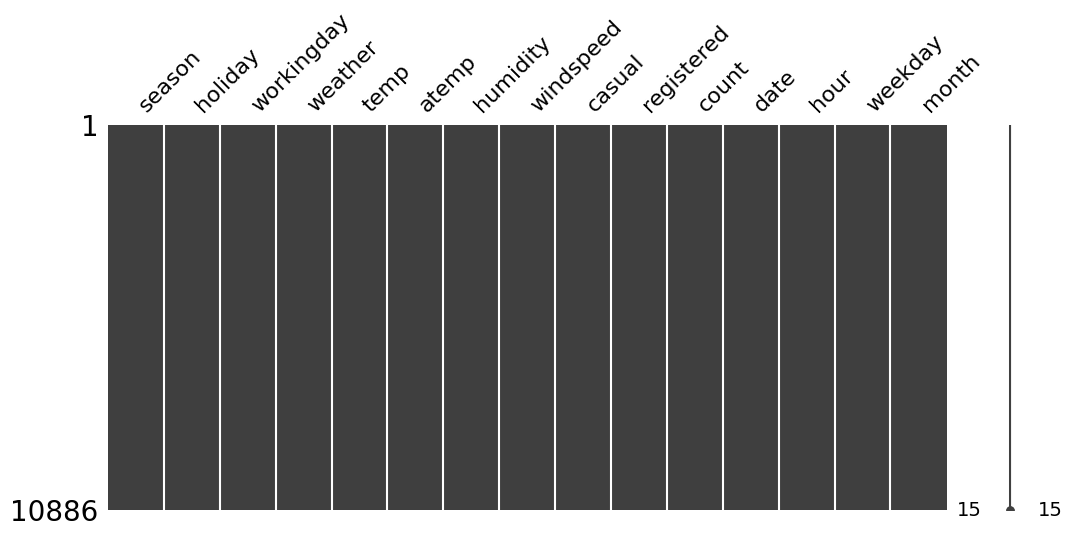

In [12]:
msno.matrix(dailyData,figsize=(12,5))

## การวิเคราะห์ Outliers (Outliers Analysis)

เมื่อมองแวบแรก ตัวแปร "count" มี Data points ที่เป็น Outlier จำนวนมากซึ่งทำให้การกระจายเบ้ไปทางขวา (เนื่องจากมี Data points มากกว่าที่อยู่นอก Outer Quartile Limit) นอกจากนั้น ข้อสรุปต่อไปนี้ยังสามารถทำได้จาก Boxplots ง่ายๆ ด้านล่าง

 - ฤดูใบไม้ผลิ (Spring season) มีจำนวนการเช่าค่อนข้างต่ำ การลดลงของค่า Median ใน Boxplot เป็นหลักฐานสำหรับเรื่องนี้
 - Boxplot กับ "Hour Of The Day" ค่อนข้างน่าสนใจ ค่า Median ค่อนข้างสูงที่ 7AM - 8AM และ 5PM - 6PM ซึ่งอาจเป็นเพราะผู้ใช้ที่เป็นนักเรียนและพนักงานออฟฟิศทั่วไปในเวลานั้น
 - จุด Outlier ส่วนใหญ่มาจาก "Working Day" มากกว่า "Non Working Day" ซึ่งเห็นได้ชัดจากรูปที่ 4

[Text(0.5, 0, 'Working Day'),
 Text(0, 0.5, 'Count'),
 Text(0.5, 1.0, 'Box Plot On Count Across Working Day')]

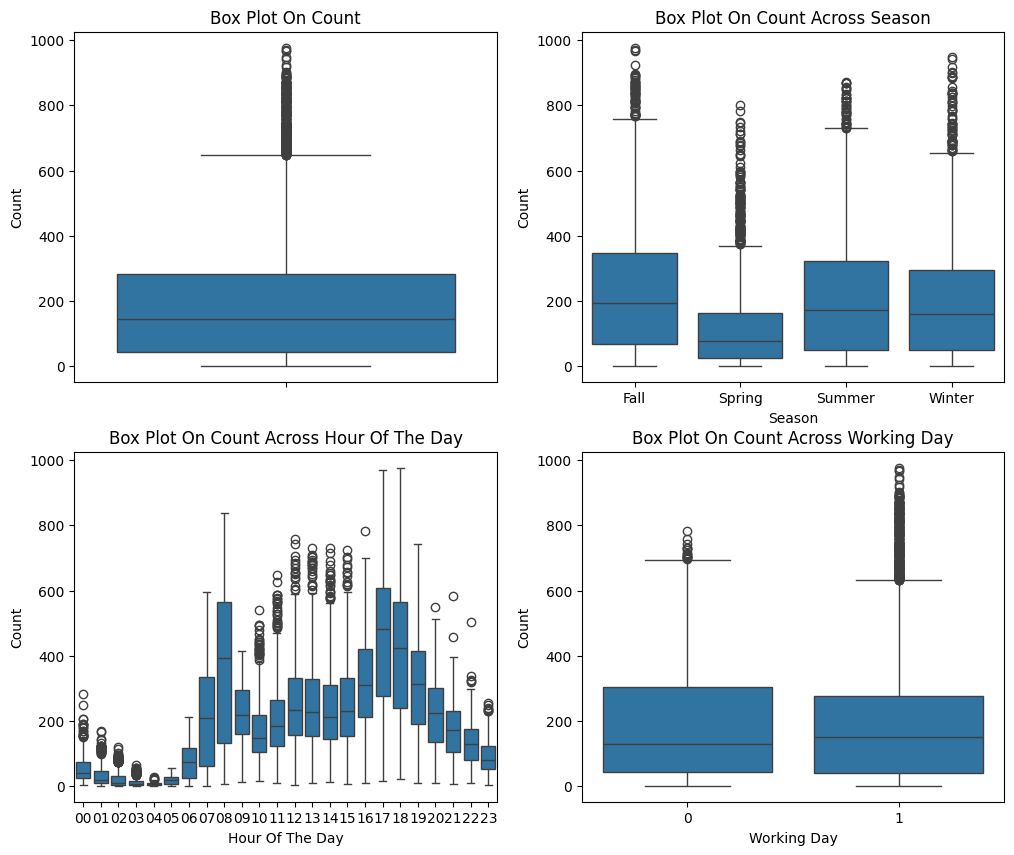

In [13]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(12, 10)
sn.boxplot(data=dailyData,y="count",orient="v",ax=axes[0][0])
sn.boxplot(data=dailyData,y="count",x="season",orient="v",ax=axes[0][1])
sn.boxplot(data=dailyData,y="count",x="hour",orient="v",ax=axes[1][0])
sn.boxplot(data=dailyData,y="count",x="workingday",orient="v",ax=axes[1][1])

axes[0][0].set(ylabel='Count',title="Box Plot On Count")
axes[0][1].set(xlabel='Season', ylabel='Count',title="Box Plot On Count Across Season")
axes[1][0].set(xlabel='Hour Of The Day', ylabel='Count',title="Box Plot On Count Across Hour Of The Day")
axes[1][1].set(xlabel='Working Day', ylabel='Count',title="Box Plot On Count Across Working Day")

#### **มาลบ Outliers ในคอลัมน์ Count กัน (Lets Remove Outliers In The Count Column)**

In [14]:
dailyDataWithoutOutliers = dailyData[np.abs(dailyData["count"]-dailyData["count"].mean())<=(3*dailyData["count"].std())] 

In [15]:
print ("Shape Of The Before Ouliers: ",dailyData.shape)
print ("Shape Of The After Ouliers: ",dailyDataWithoutOutliers.shape)

Shape Of The Before Ouliers:  (10886, 15)
Shape Of The After Ouliers:  (10739, 15)


## การวิเคราะห์ Correlation (Correlation Analysis)

วิธีทั่วไปในการเข้าใจว่าตัวแปรตาม (Dependent variable) ได้รับอิทธิพลจากฟีเจอร์ (Numerical) อย่างไรคือการหา Correlation matrix ระหว่างพวกมัน มาพล็อต Correlation plot ระหว่าง "count" และ ["temp","atemp","humidity","windspeed"]

 - ฟีเจอร์ temp และ humidity มี Correlation เป็นบวกและลบกับ count ตามลำดับ แม้ว่า Correlation ระหว่างพวกมันจะไม่เด่นชัดนัก แต่ตัวแปร count ก็ยังมีความขึ้นอยู่เล็กน้อยกับ "temp" และ "humidity"
 - windspeed จะไม่เป็นฟีเจอร์ Numerical ที่มีประโยชน์จริงๆ และเห็นได้จากค่า Correlation กับ "count"
 - ตัวแปร "atemp" จะไม่ถูกนำมาพิจารณาเนื่องจาก "atemp" และ "temp" มี Correlation ที่แข็งแกร่งต่อกัน ในระหว่างการสร้างโมเดล ตัวแปรใดตัวหนึ่งต้องถูกทิ้งไปเนื่องจากพวกมันจะแสดง Multicollinearity ในข้อมูล
 - "Casual" และ "Registered" ก็ไม่ถูกนำมาพิจารณาเช่นกันเนื่องจากพวกมันเป็น Leakage variables โดยธรรมชาติและจำเป็นต้องทิ้งไประหว่างการสร้างโมเดล

Regression plot ใน seaborn เป็นวิธีที่มีประโยชน์ในการแสดงความสัมพันธ์ระหว่างสองฟีเจอร์ ที่นี่เราพิจารณา "count" vs "temp", "humidity", "windspeed"

<Axes: >

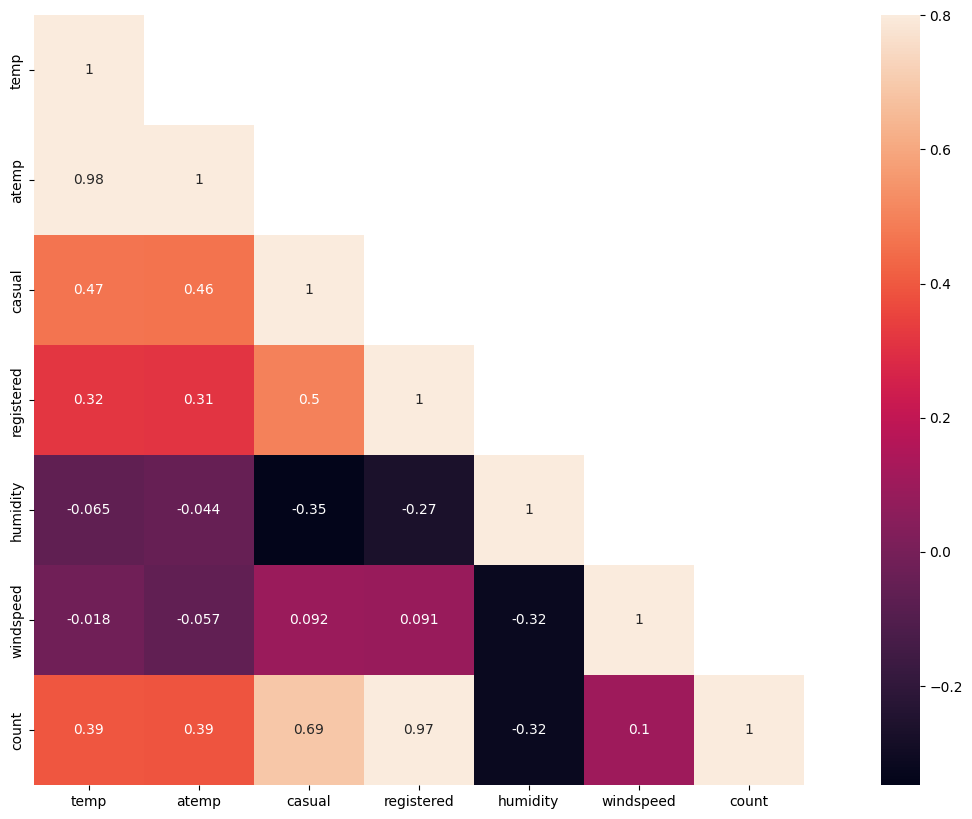

In [16]:
corrMatt = dailyData[["temp","atemp","casual","registered","humidity","windspeed","count"]].corr()
mask = np.array(corrMatt)
mask[np.tril_indices_from(mask)] = False
fig,ax= plt.subplots()
fig.set_size_inches(20,10)
sn.heatmap(corrMatt, mask=mask,vmax=.8, square=True,annot=True)

<Axes: xlabel='humidity', ylabel='count'>

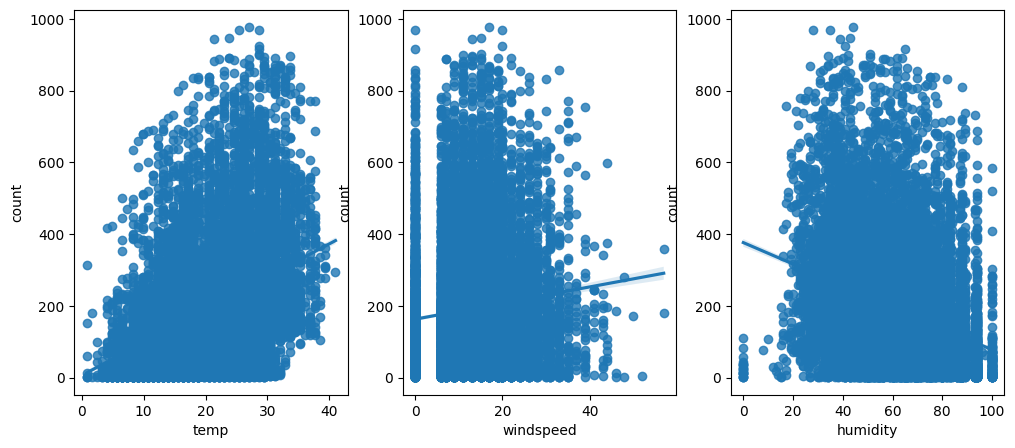

In [17]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3)
fig.set_size_inches(12, 5)
sn.regplot(x="temp", y="count", data=dailyData,ax=ax1)
sn.regplot(x="windspeed", y="count", data=dailyData,ax=ax2)
sn.regplot(x="humidity", y="count", data=dailyData,ax=ax3)

## การแสดงภาพการกระจายของข้อมูล (Visualizing Distribution Of Data)

จากรูปด้านล่างจะเห็นได้ชัดว่าตัวแปร "count" เบ้ไปทางขวา เป็นที่น่าพอใจที่จะมีการแจกแจงแบบ Normal distribution เนื่องจากเทคนิค Machine learning ส่วนใหญ่ต้องการให้ตัวแปรตามเป็น Normal วิธีแก้ปัญหาที่เป็นไปได้คือการใช้ Log transformation กับตัวแปร "count" หลังจากลบจุด Outlier data ออก หลังจาก Transformation ข้อมูลดูดีขึ้นมากแต่ยังคงไม่เป็น Normal distribution อย่างสมบูรณ์แบบ

/tmp/ipykernel_751408/4097800041.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(dailyData["count"],ax=axes[0][0])
/tmp/ipykernel_751408/4097800041.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(np.log(dailyDataWithoutOutliers["count"]),ax=axes[1][0])


((array([-3.82819677, -3.60401975, -3.48099008, ...,  3.48099008,
          3.60401975,  3.82819677]),
  array([0.69314718, 0.69314718, 0.69314718, ..., 6.5971457 , 6.59850903,
         6.5998705 ])),
 (np.float64(1.3486990121229776),
  np.float64(4.562423868087808),
  np.float64(0.9581176780909617)))

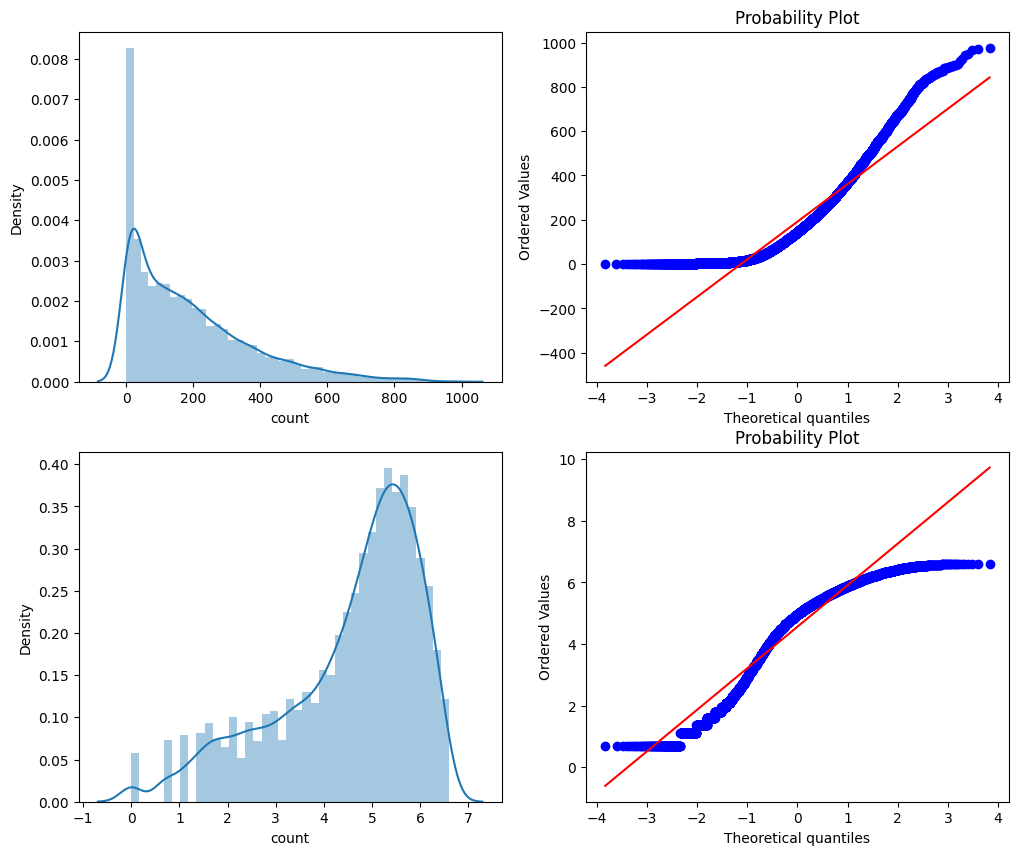

In [18]:
fig,axes = plt.subplots(ncols=2,nrows=2)
fig.set_size_inches(12, 10)
sn.distplot(dailyData["count"],ax=axes[0][0])
stats.probplot(dailyData["count"], dist='norm', fit=True, plot=axes[0][1])
sn.distplot(np.log(dailyDataWithoutOutliers["count"]),ax=axes[1][0])
stats.probplot(np.log1p(dailyDataWithoutOutliers["count"]), dist='norm', fit=True, plot=axes[1][1])

## การแสดงภาพ Count Vs (Month, Season, Hour, Weekday, Usertype)

 - ค่อนข้างชัดเจนว่าผู้คนมีแนวโน้มที่จะเช่ารถจักรยานในช่วงฤดูร้อน (Summer season) เนื่องจากเอื้อต่อการขี่จักรยานในฤดูนั้น ดังนั้นเดือนมิถุนายน กรกฎาคม และสิงหาคม จึงมีความต้องการจักรยานค่อนข้างสูงกว่า
 - ในวันธรรมดา (Weekdays) ผู้คนมักจะเช่ารถจักรยานประมาณ 7AM-8AM และ 5PM-6PM ดังที่เรากล่าวไว้ก่อนหน้านี้ สิ่งนี้อาจเป็นเพราะผู้เดินทางไปโรงเรียนและที่ทำงานเป็นประจำ
 - รูปแบบข้างต้นไม่พบใน "Saturday" และ "Sunday" ผู้คนมักจะเช่ารถจักรยานระหว่าง 10AM ถึง 4PM มากกว่า
 - จำนวนผู้ใช้สูงสุดประมาณ 7AM-8AM และ 5PM-6PM นั้นมาจากผู้ใช้ที่ลงทะเบียน (Registered user) ล้วนๆ

/tmp/ipykernel_751408/3740900214.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthAggregated = pd.DataFrame(dailyData.groupby("month")["count"].mean()).reset_index()
/tmp/ipykernel_751408/3740900214.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourAggregated = pd.DataFrame(dailyData.groupby(["hour","season"],sort=True)["count"].mean()).reset_index()
/tmp/ipykernel_751408/3740900214.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sn.pointplot(x=hourAggregated["hour"], y=hourAggregated["count"],hue=hourAggregated["season"], data=hourAggregated, join=Tr

[Text(0.5, 0, 'Hour Of The Day'),
 Text(0, 0.5, 'Users Count'),
 Text(0.5, 1.0, 'Average Users Count By Hour Of The Day Across User Type'),
 None]

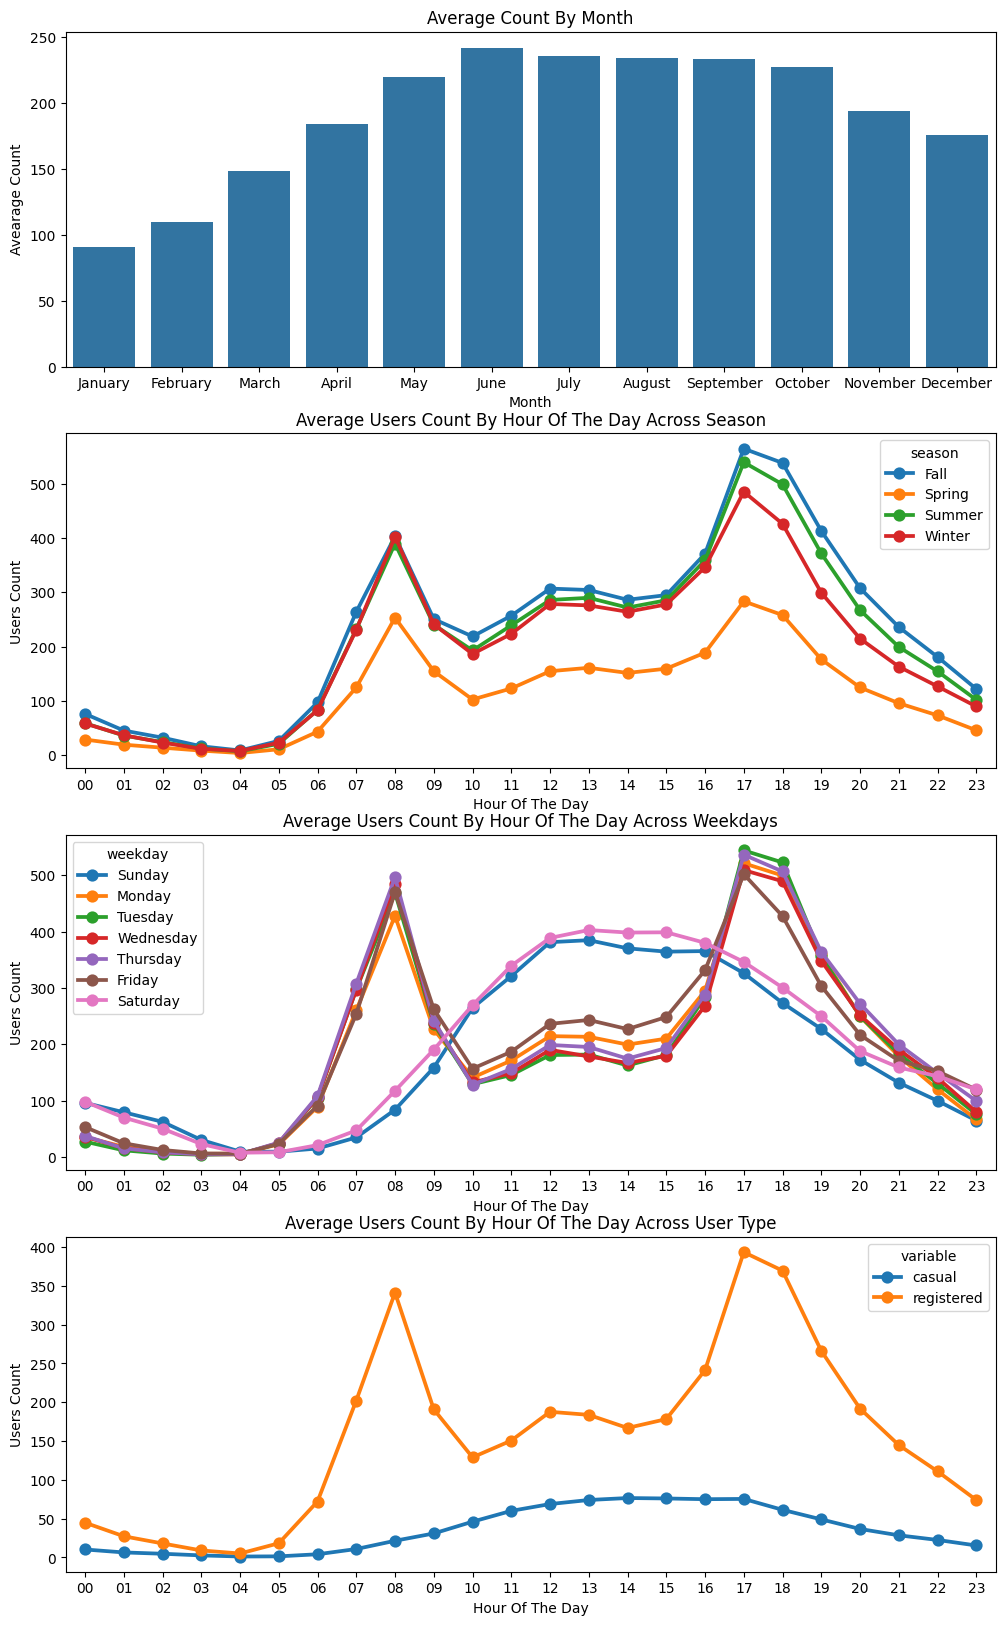

In [19]:
fig,(ax1,ax2,ax3,ax4)= plt.subplots(nrows=4)
fig.set_size_inches(12,20)
sortOrder = ["January","February","March","April","May","June","July","August","September","October","November","December"]
hueOrder = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]

monthAggregated = pd.DataFrame(dailyData.groupby("month")["count"].mean()).reset_index()
monthSorted = monthAggregated.sort_values(by="count",ascending=False)
sn.barplot(data=monthSorted,x="month",y="count",ax=ax1,order=sortOrder)
ax1.set(xlabel='Month', ylabel='Avearage Count',title="Average Count By Month")

hourAggregated = pd.DataFrame(dailyData.groupby(["hour","season"],sort=True)["count"].mean()).reset_index()
sn.pointplot(x=hourAggregated["hour"], y=hourAggregated["count"],hue=hourAggregated["season"], data=hourAggregated, join=True,ax=ax2)
ax2.set(xlabel='Hour Of The Day', ylabel='Users Count',title="Average Users Count By Hour Of The Day Across Season",label='big')

hourAggregated = pd.DataFrame(dailyData.groupby(["hour","weekday"],sort=True)["count"].mean()).reset_index()
sn.pointplot(x=hourAggregated["hour"], y=hourAggregated["count"],hue=hourAggregated["weekday"],hue_order=hueOrder, data=hourAggregated, join=True,ax=ax3)
ax3.set(xlabel='Hour Of The Day', ylabel='Users Count',title="Average Users Count By Hour Of The Day Across Weekdays",label='big')

hourTransformed = pd.melt(dailyData[["hour","casual","registered"]], id_vars=['hour'], value_vars=['casual', 'registered'])
hourAggregated = pd.DataFrame(hourTransformed.groupby(["hour","variable"],sort=True)["value"].mean()).reset_index()
sn.pointplot(x=hourAggregated["hour"], y=hourAggregated["value"],hue=hourAggregated["variable"],hue_order=["casual","registered"], data=hourAggregated, join=True,ax=ax4)
ax4.set(xlabel='Hour Of The Day', ylabel='Users Count',title="Average Users Count By Hour Of The Day Across User Type",label='big')

**ดังนั้นเราได้แสดงภาพข้อมูลไปมากแล้ว มาสร้างโมเดลและดูว่าเราสามารถทำนายผลลัพธ์ได้ใกล้เคียงแค่ไหน**

## การเติม 0 ใน Windspeed โดยใช้ Random Forest ##

**อ่านข้อมูล Train และ Test (Lets Read In Train And Test Data)**

In [20]:
dataTrain = pd.read_csv("train.csv")
dataTest = pd.read_csv("test.csv")

**รวม Train และ Test (Combine Train And Test)**

In [25]:
data = pd.concat([dataTrain, dataTest], sort=False).reset_index(drop=True)
data.reset_index(inplace=True)
data.drop('index',inplace=True,axis=1)

**Feature Engineering**

In [26]:
data["date"] = data.datetime.apply(lambda x : x.split()[0])
data["hour"] = data.datetime.apply(lambda x : x.split()[1].split(":")[0]).astype("int")
data["year"] = data.datetime.apply(lambda x : x.split()[0].split("-")[0])
data["weekday"] = data.date.apply(lambda dateString : datetime.strptime(dateString,"%Y-%m-%d").weekday())
data["month"] = data.date.apply(lambda dateString : datetime.strptime(dateString,"%Y-%m-%d").month)

**Random Forest Model เพื่อทำนาย 0 ใน Windspeed**

In [28]:
from sklearn.ensemble import RandomForestRegressor

dataWind0 = data[data["windspeed"]==0]
dataWindNot0 = data[data["windspeed"]!=0]
rfModel_wind = RandomForestRegressor()
windColumns = ["season","weather","humidity","month","temp","year","atemp"]
rfModel_wind.fit(dataWindNot0[windColumns], dataWindNot0["windspeed"])

wind0Values = rfModel_wind.predict(X= dataWind0[windColumns])
dataWind0["windspeed"] = wind0Values
data = pd.concat([data, dataWindNot0], sort=False)
data.reset_index(inplace=True)
data.drop('index',inplace=True,axis=1)

**บังคับเป็นประเภท Categorical (Coercing To Categorical Type)**

In [29]:
categoricalFeatureNames = ["season","holiday","workingday","weather","weekday","month","year","hour"]
numericalFeatureNames = ["temp","humidity","windspeed","atemp"]
dropFeatures = ['casual',"count","datetime","date","registered"]

In [30]:
for var in categoricalFeatureNames:
    data[var] = data[var].astype("category")

**แบ่งข้อมูล Train และ Test (Splitting Train And Test Data)**

In [31]:
dataTrain = data[pd.notnull(data['count'])].sort_values(by=["datetime"])
dataTest = data[~pd.notnull(data['count'])].sort_values(by=["datetime"])
datetimecol = dataTest["datetime"]
yLabels = dataTrain["count"]
yLablesRegistered = dataTrain["registered"]
yLablesCasual = dataTrain["casual"]

**ลบตัวแปรที่ไม่จำเป็น (Dropping Unncessary Variables)**

In [32]:
dataTrain  = dataTrain.drop(dropFeatures,axis=1)
dataTest  = dataTest.drop(dropFeatures,axis=1)

In [33]:
dataTrain.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,hour,year,weekday,month
0,1,0,0,1,9.84,14.395,81,0.0,0,2011,5,1
1,1,0,0,1,9.02,13.635,80,0.0,1,2011,5,1
2,1,0,0,1,9.02,13.635,80,0.0,2,2011,5,1
3,1,0,0,1,9.84,14.395,75,0.0,3,2011,5,1
4,1,0,0,1,9.84,14.395,75,0.0,4,2011,5,1


In [35]:
dataTrain.dtypes

season        category
holiday       category
workingday    category
weather       category
temp           float64
atemp          float64
humidity         int64
windspeed      float64
hour          category
year          category
weekday       category
month         category
dtype: object

**RMSLE Scorer**

In [26]:
def rmsle(y, y_,convertExp=True):
    if convertExp:
        y = np.exp(y),
        y_ = np.exp(y_)
    log1 = np.nan_to_num(np.array([np.log(v + 1) for v in y]))
    log2 = np.nan_to_num(np.array([np.log(v + 1) for v in y_]))
    calc = (log1 - log2) ** 2
    return np.sqrt(np.mean(calc))

## **Linear Regression Model** ##

In [27]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import warnings
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Initialize logistic regression model
lModel = LinearRegression()

# Train the model
yLabelsLog = np.log1p(yLabels)
lModel.fit(X = dataTrain,y = yLabelsLog)

# Make predictions
preds = lModel.predict(X= dataTrain)
print ("RMSLE Value For Linear Regression: ",rmsle(np.exp(yLabelsLog),np.exp(preds),False))

RMSLE Value For Linear Regression:  0.977995978355


## **Regularization Model - Ridge** ##

{'alpha': 0.1, 'max_iter': 3000}
RMSLE Value For Ridge Regression:  0.97799596327


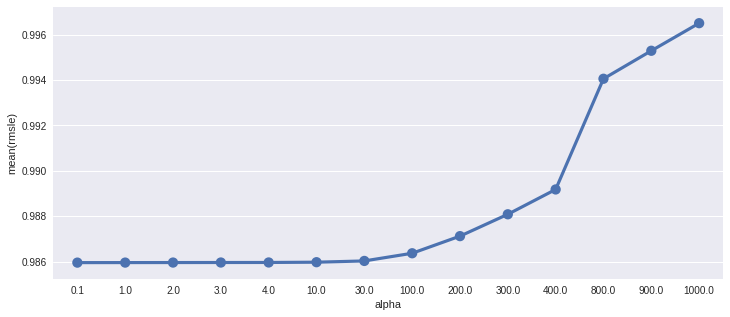

In [28]:
ridge_m_ = Ridge()
ridge_params_ = { 'max_iter':[3000],'alpha':[0.1, 1, 2, 3, 4, 10, 30,100,200,300,400,800,900,1000]}
rmsle_scorer = metrics.make_scorer(rmsle, greater_is_better=False)
grid_ridge_m = GridSearchCV( ridge_m_,
                          ridge_params_,
                          scoring = rmsle_scorer,
                          cv=5)
yLabelsLog = np.log1p(yLabels)
grid_ridge_m.fit( dataTrain, yLabelsLog )
preds = grid_ridge_m.predict(X= dataTrain)
print (grid_ridge_m.best_params_)
print ("RMSLE Value For Ridge Regression: ",rmsle(np.exp(yLabelsLog),np.exp(preds),False))

fig,ax= plt.subplots()
fig.set_size_inches(12,5)
df = pd.DataFrame(grid_ridge_m.grid_scores_)
df["alpha"] = df["parameters"].apply(lambda x:x["alpha"])
df["rmsle"] = df["mean_validation_score"].apply(lambda x:-x)
sn.pointplot(data=df,x="alpha",y="rmsle",ax=ax)

## **Regularization Model - Lasso** ##

{'alpha': 0.0050000000000000001, 'max_iter': 3000}
RMSLE Value For Lasso Regression:  0.978133604313


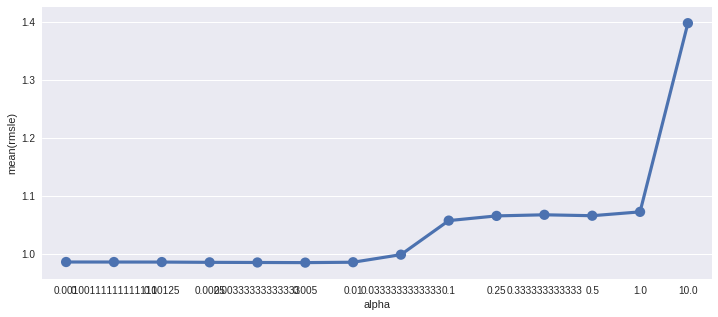

In [29]:
lasso_m_ = Lasso()

alpha  = 1/np.array([0.1, 1, 2, 3, 4, 10, 30,100,200,300,400,800,900,1000])
lasso_params_ = { 'max_iter':[3000],'alpha':alpha}

grid_lasso_m = GridSearchCV( lasso_m_,lasso_params_,scoring = rmsle_scorer,cv=5)
yLabelsLog = np.log1p(yLabels)
grid_lasso_m.fit( dataTrain, yLabelsLog )
preds = grid_lasso_m.predict(X= dataTrain)
print (grid_lasso_m.best_params_)
print ("RMSLE Value For Lasso Regression: ",rmsle(np.exp(yLabelsLog),np.exp(preds),False))

fig,ax= plt.subplots()
fig.set_size_inches(12,5)
df = pd.DataFrame(grid_lasso_m.grid_scores_)
df["alpha"] = df["parameters"].apply(lambda x:x["alpha"])
df["rmsle"] = df["mean_validation_score"].apply(lambda x:-x)
sn.pointplot(data=df,x="alpha",y="rmsle",ax=ax)

## **Ensemble Models - Random Forest** ##

In [30]:
from sklearn.ensemble import RandomForestRegressor
rfModel = RandomForestRegressor(n_estimators=100)
yLabelsLog = np.log1p(yLabels)
rfModel.fit(dataTrain,yLabelsLog)
preds = rfModel.predict(X= dataTrain)
print ("RMSLE Value For Random Forest: ",rmsle(np.exp(yLabelsLog),np.exp(preds),False))

RMSLE Value For Random Forest:  0.102804484141


## **Ensemble Model - Gradient Boost** ##

In [31]:
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor(n_estimators=4000,alpha=0.01); ### Test 0.41
yLabelsLog = np.log1p(yLabels)
gbm.fit(dataTrain,yLabelsLog)
preds = gbm.predict(X= dataTrain)
print ("RMSLE Value For Gradient Boost: ",rmsle(np.exp(yLabelsLog),np.exp(preds),False))

RMSLE Value For Gradient Boost:  0.189973542608


**มาเปรียบเทียบการกระจายของผลลัพธ์ Train และ Test กัน การกระจายของ Train และ Test ดูเหมือนจะเหมือนกันไม่มากก็น้อย เป็นการยืนยันด้วยสายตาว่าโมเดลของเราไม่ได้ทำนายแย่จริงๆ และไม่ได้ประสบปัญหา Overfitting ที่สำคัญ**

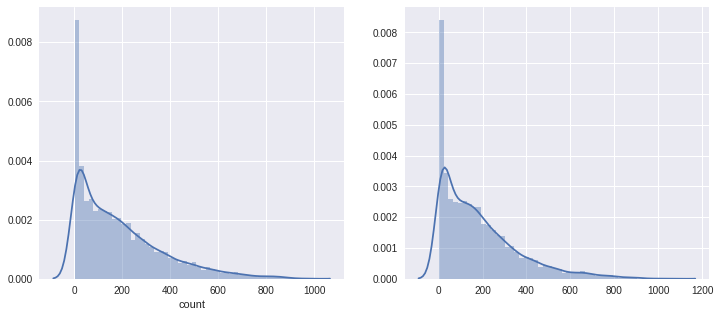

In [32]:
predsTest = gbm.predict(X= dataTest)
fig,(ax1,ax2)= plt.subplots(ncols=2)
fig.set_size_inches(12,5)
sn.distplot(yLabels,ax=ax1,bins=50)
sn.distplot(np.exp(predsTest),ax=ax2,bins=50)

In [33]:
submission = pd.DataFrame({
        "datetime": datetimecol,
        "count": [max(0, x) for x in np.exp(predsTest)]
    })
submission.to_csv('bike_predictions_gbm_separate_without_fe.csv', index=False)

**การส่งผลลัพธ์จะมีคะแนน Test score ที่ 0.41**